# Lecture 3
### Timing | Simulating a Heterogeneous Population

**Computational Methods for Heterogeneous-Agent Macro**

Jeffrey Sun

**Note:** This code is not very optimized. I am using allocating functions, plain grid search, no Howard improvement, etc., etc.. I wrote it to be clear rather than fast. The fast versions are in $\texttt{HouseholdStages.jl}$.

### Environment


In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()

using Plots, Random, LinearAlgebra, Plots.PlotMeasures, Interpolations
using Statistics: mean

  Activating project at `~/projects/research/CV is all you need`


# Core Code


### Parameters

We add in a stochastic process for human capital $z$, and its relevant parameters.

Human capital $z$ now follows a Markov chain with states `z_grid` and transition matrix `Π_z`.

In [2]:
u(c) = c <= 0 ? -Inf : log(c)
loggrid(lo, hi, N) = exp.(range(log(lo), log(hi); length=N))
snap_idx(grid, x) = argmin(abs.(grid .- x))

snap_idx (generic function with 1 method)

In [3]:
function get_params(;
        β=0.96,
        R=1.04,
        b_grid=loggrid(0.05, 200.0, 1000),
        z_grid=[2.7, 2.0, 1.5],
        Π_z=[0.95 0.04 0.01;
           0.05 0.9  0.05;
           0.01 0.04 0.95],
    )

    return params = (;β, R,
                    V_shape=(length(b_grid), length(z_grid)),
                    b_grid, z_grid, Π_z)
end

get_params (generic function with 1 method)

## Stages

We now decompose the model into stage and implement each one separately. This is immensely helpful once household blocks start to become the least bit complicated.

### Backwards Iteration

The three stages compose into one backward step on a 2-D value function
$V \in \mathbb{R}^{N_b \times N_z}$. Each stage maps one labelled $V$ to the next:

- **Stage 3 (Consumption-Saving) backward.** Grid-search $V^\text{end} \mapsto V^\text{pre\_cons}$.
- **Stage 2 (Income) backward.** Linearly interpolate $V^\text{pre\_cons} \mapsto V^\text{pre\_inc}$ at $V^\text{pre\_inc}(b) = V^\text{pre\_cons}(R b + z_j)$.
- **Stage 1 (Income Shock) backward.** Matrix-multiply $V^\text{pre\_inc} \mapsto V^\text{pre\_shock}$ by $\Pi^\top$.

- **Stage 0 (Time discounting).** $V^\text{start} = \beta\, V^\text{pre\_shock}$.


In [4]:
"Stage 1 (Income Shock) backward."
income_shock_backward(V_post_inc_shock, params) = V_post_inc_shock * params.Π_z'

"Stage 2 (Income) backward."
function income_backward(V_post_inc, params)
    # Unpack params
    (;R, b_grid, z_grid) = params

    # Allocate output array
    V_pre_inc = similar(V_post_inc)

    # Linearly interpolate V_post_inc onto V_pre_inc for each z_j
    for j in axes(V_post_inc, 2)
        itp = linear_interpolation(b_grid, V_post_inc[:, j]; extrapolation_bc=Flat())
        V_pre_inc[:, j] .= itp.(R .* b_grid .+ z_grid[j])
    end
    return V_pre_inc
end

"Stage 3 (Consumption-Saving) backward."
function consumption_saving_backward(V_end, params)
    # Unpack b_grid
    (;b_grid) = params

    # Move b_grid to dimension 3 to represent b_end choices
    b_next_grid = insertdims(b_grid; dims=(1,2))

    # Move b_grid part of V_end to dimension 3 to represent b_end choices
    # V_end_reshape shape is now [1, z_grid, b_grid]
    V_end_reshape = insertdims(permutedims(V_end, (2,1)); dims=1)

    # Maximize along b_end dimension (dim=3)
    V = maximum(u.(b_grid .- b_next_grid) .+ V_end_reshape; dims=3)

    # Drop dimension 3 from V and return
    return dropdims(V; dims=3)
end

consumption_saving_backward

In [5]:
"Iterate V_end backwards by one full period."
function bellman_operator(V_end, params)
    (;β) = params

    # Stage 3
    V_post_inc = consumption_saving_backward(V_end, params)

    # Stage 2
    V_post_inc_shock = income_backward(V_post_inc, params)

    # Stage 1
    V_start = income_shock_backward(V_post_inc_shock, params)

    # Stage 0
    V_end_new = β .* V_start

    return V_end_new
end

bellman_operator

### Value Function Iteration (Same as last time!)

Iterate $V \mapsto \mathcal{T}V$ until the max-abs change drops below `rtol`.

Note that this is **independent** of the stage implementation. A similar thing is true of many outer loops. This modularity is useful for building complex models in an easy, standard, transparent way.

In [6]:
function solve_vfi(params; rtol=1e-6, maxiter=2000, verbosity=0)
    
    # Make initial guess of V
    V = zeros(params.V_shape)

    # Repeatedly apply Bellman operator until convergence
    Δ = Inf
    iters = 0
    while Δ >= rtol
        # Update V
        TV = bellman_operator(V, params)

        # Calculate error
        Δ = maximum(abs.(TV .- V))

        # Update V
        V = TV
        
        # Housekeeping
        verbosity >= 2 && println("Iteration $iters: Δ = $Δ")
        iters = iters + 1
        iters > maxiter && error("VFI did not converge in $maxiter iterations")
    end
    verbosity >= 1 && println("VFI converged in $iters iterations with error $Δ")

    return V
end

# Try it!
# params = get_params()
# V_end = solve_vfi(params; verbosity=1)

solve_vfi (generic function with 1 method)

### Policy Function

In [7]:
function policy_function(V_end, params)
    # Unpack b_grid
    (;b_grid) = params

    # Move b_grid to dimension 3 to represent b_end choices
    b_next_grid = insertdims(b_grid; dims=(1,2))

    # Move b_grid part of V_end to dimension 3 to represent b_end choices
    # V_end_reshape shape is now [1, z_grid, b_grid]
    V_end_reshape = insertdims(permutedims(V_end, (2,1)); dims=1)

    # Maximize along b_end dimension (dim=3)
    policy_idxs = argmax(u.(b_grid .- b_next_grid) .+ V_end_reshape; dims=3)

    return [idx[3] for idx in policy_idxs[:,:,1]]
end

policy_function (generic function with 1 method)

### A Population is an Array (Vector, Matrix, etc.)

A *population* can be thought of as a *distribution* over state variables.

If $b$ is the only state variable, then a *population* is just a vector $\Lambda$, with $\Lambda_i$ = "number of people with wealth $b_i$."

If $(b, z)$ are the state variables, the population is a matrix $\Lambda$, with $\Lambda_{ij}$ = "number of people with wealth $b_i$ and human capital $z_j$."

(But of course matrices are a kind of vector.)

### Forward iteration in stages

We can simulate each population matrix forward though each stage, one at a time.

- **Stage 1 (Income Shock) forward.** $\Lambda \mapsto \Lambda\, \Pi$.
- **Stage 2 (Income) forward.** Each $(b^{\mathrm{end}}, z)$ cell moves to $(R\,b^{\mathrm{end}} + z_{\mathrm{grid}}[j],\, z)$.
- **Stage 3 (Consumption-Saving) forward.** Each $(b, z)$ cell moves to $(b - c^\star(b, z),\, z)$.

In [8]:
# Stage 1 #
#---------#
"Stage 1 forward: Λ_post = Λ_pre * Π_z."
income_shock_forward(Λ, Π_z) = Λ * Π_z

# Stage 2 #
#---------#
"General method for simulating a wealth change as a reinterpolation of one population distribution onto another."
function change_Λ_wealth(Λ, b_inds_new)
    Λ_new = zero(Λ)
    for old_idx in CartesianIndices(Λ)
        Λ_new[b_inds_new[old_idx], old_idx[2]] += Λ[old_idx]
    end
    return Λ_new
end

"Stage 2 forward: each (i_b_end, i_z) cell moves to (snap(R*b_end + z), i_z)."
function income_forward(Λ, params)
    (;R, b_grid, z_grid) = params
    dest = snap_idx.(Ref(b_grid), R .* b_grid .+ z_grid')               # (N_b, N_z)
    return change_Λ_wealth(Λ, dest)
end

# Stage 3 #
#---------#
"Stage 3 forward: each (i_b, i_z) cell moves to (c_ind[i_b, i_z], i_z)."
consumption_saving_forward(Λ, b_inds_new, params) = change_Λ_wealth(Λ, b_inds_new)

"Simulate population forward through all three Stages: Λ → income shock → income → consumption saving."
function simulate_population_forward(Λ, b_inds_new, params)
    # Stage 1
    Λ = income_shock_forward(Λ, params.Π_z)

    # Stage 2
    Λ = income_forward(Λ, params)

    # Stage 3
    Λ = consumption_saving_forward(Λ, b_inds_new, params)

    return Λ
end

simulate_population_forward

In [9]:
"Simulate population forward for T periods."
function simulate_population_forward(Λ, b_inds_new, params, T)
    for t=1:T
        Λ = simulate_population_forward(Λ, b_inds_new, params)
    end
    return Λ
end

"Find steady state population distribution Λ by simulating forward to convergence."
function find_steady_state_population(V_end, params; rtol=1e-5, maxiter=10_000, verbosity=0)

    # Compute policy function *only once* as it is fully determined by V_end.
    b_inds_new = policy_function(V_end, params)

    # Initialize population distribution. (If model is well-behaved, initial distribution shouldn't matter.)
    Λ = fill(1/length(params.V_shape), params.V_shape)

    # Iterate Λ forward until convergence
    Δ, iters = Inf, 0
    while Δ >= rtol
        # Simulate forward 100 steps
        Λ = simulate_population_forward(Λ, b_inds_new, params, 100)

        # Check convergence
        Λ_new = simulate_population_forward(Λ, b_inds_new, params)
        Δ = maximum(abs.(Λ_new .- Λ)./mean(Λ))
        Λ = Λ_new

        # Housekeeping
        verbosity >= 2 && println("Iteration $iters: Δ = $Δ")
        iters += 1
        iters > maxiter && error("Steady state Λ did not converge in $maxiter iterations")
    end

    verbosity >= 1 && println("Steady state Λ converged in $iters iterations with error $Δ")
    return Λ
end

find_steady_state_population

## Demo


### Plot Λ

VFI converged in 344 iterations with error 9.669925091770892e-7
Steady state Λ converged in 18 iterations with error 8.835743471991373e-6


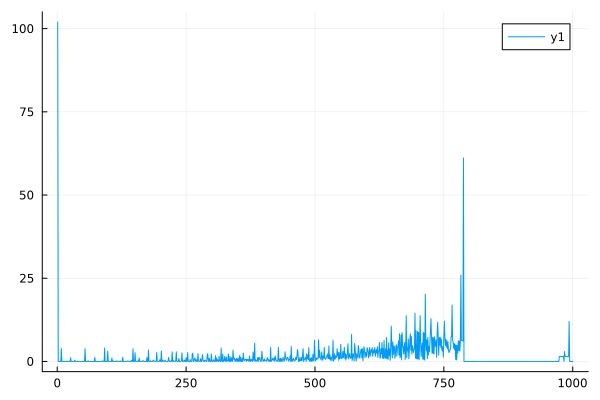

In [10]:
params = get_params()
V_steady_state = solve_vfi(params; verbosity=1)
Λ_steady_state = find_steady_state_population(V_steady_state, params; verbosity=1)

plot(sum(Λ_steady_state; dims=2))

### Plot $V$ and $c^\star$


Iteration 0: Δ = 5.086144641881114
Iteration 1: Δ = 3.6123000687682394
Iteration 2: Δ = 3.017074933690571
Iteration 3: Δ = 2.619140294449524
Iteration 4: Δ = 2.3187931588640627
Iteration 5: Δ = 2.077733879131305
Iteration 6: Δ = 1.8774372031804631
Iteration 7: Δ = 1.7066677894666498
Iteration 8: Δ = 1.5584081237143579
Iteration 9: Δ = 1.4290897933458382
Iteration 10: Δ = 1.3136090598204255
Iteration 11: Δ = 1.2102332624694263
Iteration 12: Δ = 1.1179414571359416
Iteration 13: Δ = 1.0337238129309263
Iteration 14: Δ = 0.9581469193591232
Iteration 15: Δ = 0.8892273094070262
Iteration 16: Δ = 0.82589924109908
Iteration 17: Δ = 0.7673502220037776
Iteration 18: Δ = 0.7143219715826774
Iteration 19: Δ = 0.6652853248418822
Iteration 20: Δ = 0.6200353073648515
Iteration 21: Δ = 0.5786138151302751
Iteration 22: Δ = 0.539597117763364
Iteration 23: Δ = 0.5041145959179048
Iteration 24: Δ = 0.47127830024738415
Iteration 25: Δ = 0.4401351654321175
Iteration 26: Δ = 0.41084774818230585
Iteration 27: Δ 

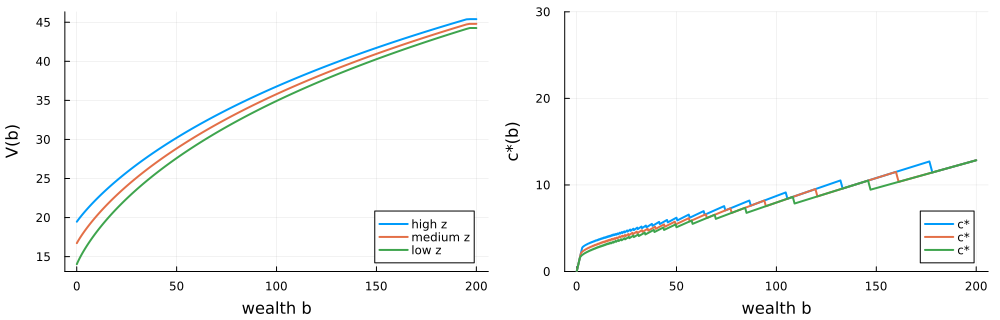

In [11]:
# Solve V by VFI
params = get_params(; R=1.01)
(;b_grid, z_grid) = params
V_end = solve_vfi(params; verbosity=2)
b_inds_new = policy_function(V_end, params)

# Turn the index vector b_inds_new back into a consumption value for plotting
c_pol = b_grid .- b_grid[b_inds_new]

# Plot V and c* for each z
p1 = plot(b_grid, V_end; lw=2, xlabel="wealth b", ylabel="V(b)",
          label=["high z" "medium z" "low z"], legend=:bottomright)
p2 = plot(b_grid, c_pol; lw=2, xlabel="wealth b", ylabel="c*(b)",
          label="c*", legend=:bottomright, ylims=(0,30))
plot(p1, p2; layout=(1, 2), size=(1000, 320), bottom_margin=5mm, left_margin=5mm)

# Note: There is some noise in the policy function here due to the simple argmax algorithm


### Simulate one household

We can also simulate a single household forward over time, taking a particular draw from their $z$ process.

Note how wealth rises when $z$ increases and falls when $z$ decreases.


In [12]:
"Draw the next state of a Markov chain with transition matrix Π_z, given current state i."
sample_markov(Π_z, i) = findfirst(rand() .<= cumsum(Π_z[i, :]))

"""
Simulate one household forward T periods using the policy `c_inds`.
"""
function simulate_one(c_inds, params; T=200, b_ind_init=1, z_ind_init=1)
    (;R, z_grid, Π_z, b_grid) = params

    # Initialize household state
    b_ind, z_ind = b_ind_init, z_ind_init

    i_b_path, i_z_path = zeros(Int, T), zeros(Int, T)
    for t in 1:T
        # Stage 1: income shock — draw next z state.
        z_ind = sample_markov(Π_z, z_ind)

        # Stage 2: realize income, assemble cash-on-hand b = R·b_end + z.
        b_cash_ind = snap_idx(b_grid, R * b_grid[b_ind] + z_grid[z_ind])

        # Stage 3: savings = policy at (cash-on-hand, z).
        b_ind = c_inds[b_cash_ind, z_ind]

        i_b_path[t], i_z_path[t] = b_cash_ind, z_ind
    end
    return (;i_b_path, i_z_path)
end

simulate_one

VFI converged in 344 iterations with error 9.669925091770892e-7


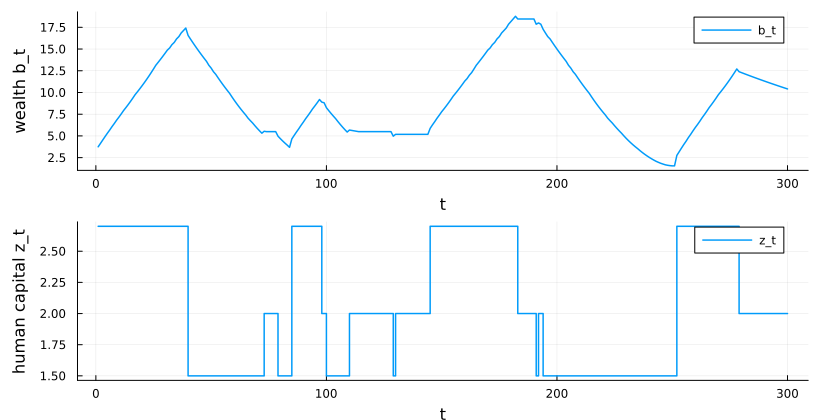

In [13]:
params = get_params()
(;b_grid, z_grid) = params
V_end = solve_vfi(params; verbosity=1)
b_inds_new = policy_function(V_end, params)


Random.seed!(1)
# start at the grid point nearest to wealth 1.0, high z
sim = simulate_one(b_inds_new, params; T=300,
                   b_ind_init=argmin(abs.(b_grid .- 1.0)), z_ind_init=1)

t_axis = 1:length(sim.i_b_path)
p1 = plot(t_axis, b_grid[sim.i_b_path]; lw=1.5,
          xlabel="t", ylabel="wealth b_t",
          label="b_t", legend=:topright)
p2 = plot(t_axis, [z_grid[z] for z in sim.i_z_path]; lw=1.5,
          xlabel="t", ylabel="human capital z_t",
          label="z_t", legend=:topright, seriestype=:steppost)
plot(p1, p2; layout=(2, 1), size=(820, 420), left_margin=5mm)

### Simulate Population

In [ ]:
params = get_params()
(;b_grid, z_grid) = params
V_end = solve_vfi(params; verbosity=1)
b_inds_new = policy_function(V_end, params)

# start everyone at wealth ≈ 1.0, high z
Λ_0 = zeros(length(b_grid), length(z_grid))
i_0 = argmin(abs.(b_grid .- 1.0))
Λ_0[i_0, 1] = 1.0

# Collect Λ trajectory over T iterations
iterations = 400
Λ_path = [Λ_0]
for i in 1:iterations
    push!(Λ_path, simulate_population_forward(Λ_path[end], b_inds_new, params))
end

VFI converged in 344 iterations with error 9.669925091770892e-7


### Evolution of aggregates

Note how mean wealth converges to the steady-state value as we iterate, given $V$.

Note that this is **not** a transition path. This is the convergence of the $\Lambda$ process given steady-state $V$.

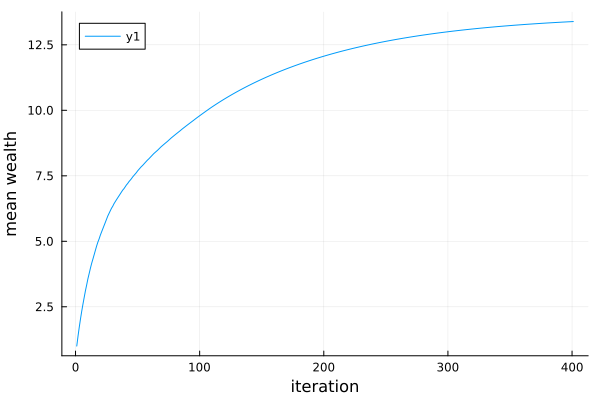

In [16]:
# Plot mean of the Λ distribution at each iteration.
plot([sum(Λ.*b_grid) for Λ in Λ_path]; xlabel="iteration", ylabel="mean wealth")

### Cross-sectional aggregates from $V$ and $c^\star$

Aggregate welfare $\bar V$, consumption $\bar C$, wealth $\bar K$ at each $t$ — all inner products against the marginal wealth distribution.


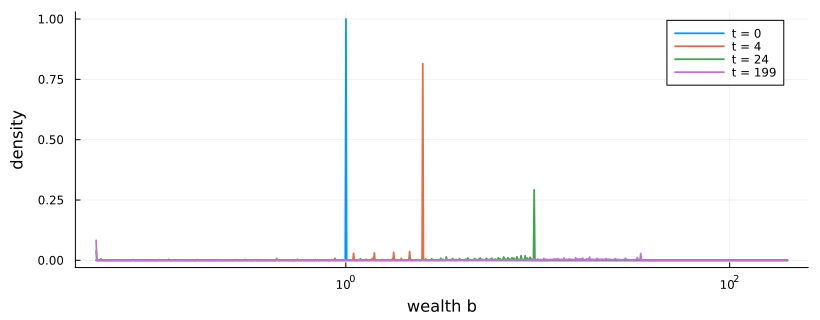

In [21]:
# Compute marginal wealth distribution
wealth_distribution(Λ) = vec(sum(Λ; dims=2))

# The marginal wealth distribution gets more spread out over time as idiosyncratic shocks
# disperse households
snapshots = [1, 5, 25, 200]
p = plot(xlabel="wealth b", ylabel="density", legend=:topright)
for t in snapshots
    plot!(p, b_grid, wealth_distribution(Λ_path[t]); lw=1.8, label="t = $(t-1)")
end
plot(p; size=(820, 320), xscale=:log10, left_margin=5mm, bottom_margin=5mm)

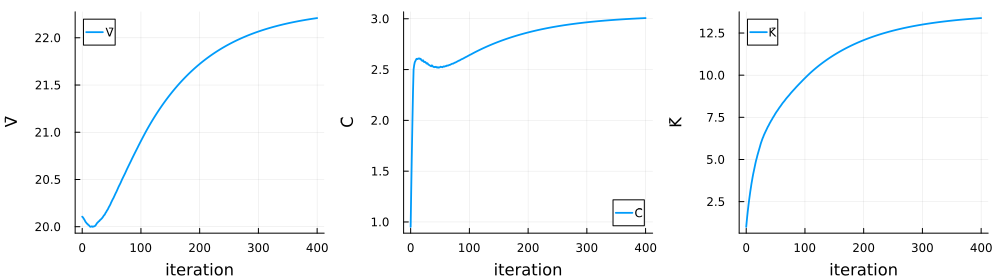

In [24]:
V_bar = [sum(V_end  .* Λ) for Λ in Λ_path]
C_bar = [sum(c_pol  .* Λ) for Λ in Λ_path]
K_bar = [dot(b_grid, wealth_distribution(Λ)) for Λ in Λ_path]

t_axis = 0:length(Λ_path)-1
p1 = plot(t_axis, V_bar; lw=1.8, xlabel="t", ylabel="V̄", label="V̄")
p2 = plot(t_axis, C_bar; lw=1.8, xlabel="t", ylabel="C̄", label="C̄")
p3 = plot(t_axis, K_bar; lw=1.8, xlabel="t", ylabel="K̄", label="K̄")
plot(p1, p2, p3; layout=(1, 3), size=(1000, 280), left_margin=5mm, bottom_margin=5mm, xlabel="iteration")